# Mapping of ontology terms to dataset labels
-- Ben De Meurichy

In [27]:
import pandas as pd
import numpy as np
import faiss
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

## Load labels from current datasets

In [28]:
import sys
sys.path.append('/home/bendm/Thesis/project/code/src')

from label_loading.load_aerosonic_db import load_aerosonic_db
from label_loading.load_birdset import load_birdset
from label_loading.load_esc50 import load_esc50
from label_loading.load_freesound import load_freesound
from label_loading.load_risoux_test import load_risoux_test

In [29]:
# Load all datasets
base_path = '/home/bendm/Thesis/project/code/data/metadata'
audio_base = '/home/bendm/Thesis/project/code/data/audio'

aerosonic = load_aerosonic_db(f'{base_path}/aerosonicDB/sample_meta.csv')
birdset = load_birdset(f'{base_path}/birdset/annotations.csv')
esc50 = load_esc50(f'{base_path}/esc50/esc50.csv')

# Note: Freesound audio files may not be available locally
# The metadata CSV exists but audio files need to be downloaded
freesound_audio_path = f'{audio_base}/Backgrounds/Background/Background'
freesound_metadata_path = f'{base_path}/freesound_curation/source_freesound_field_recordings_links_with_labels.csv'

import os
from pathlib import Path
import ast

if Path(freesound_audio_path).exists():
    freesound = load_freesound(
        audio_base_path=freesound_audio_path,
        metadata=freesound_metadata_path
    )
    print(f'Freesound audio directory found: {freesound_audio_path}')
else:
    print(f'WARNING: Freesound audio directory not found at {freesound_audio_path}')
    print('Loading labels from metadata CSV only...')
    
    # Define relevant labels to keep (related to nature, field recordings, airplanes, birds)
    RELEVANT_FREESOUND_LABELS = {
        # Nature sounds
        'nature', 'field_recording', 'fieldrecording', 'ambient', 'atmosphere',
        'soundscape', 'outdoor', 'outdoors', 'forest', 'woods', 'wilderness',
        # Weather
        'rain', 'raining', 'rainy', 'thunder', 'thunderstorm', 'storm', 'wind', 'windy',
        # Water
        'water', 'river', 'stream', 'ocean', 'sea', 'waves', 'lake', 'pond',
        'waterfall', 'brook', 'creek', 'splash', 'drip', 'drops',
        # Birds
        'bird', 'birds', 'birdsong', 'chirp', 'chirping', 'tweet', 'tweeting',
        'crow', 'raven', 'owl', 'duck', 'goose', 'seagull',
        'robin', 'sparrow', 'songbird',
        # Insects
        'insect', 'insects', 'cricket', 'crickets', 'bee', 'bees', 'fly', 'flies',
        'cicada', 'cicadas', 'buzzing', 'buzz',
        # Animals
        'frog', 'frogs', 'toad', 'animal', 'animals', 'wildlife',
        # Airplanes/aircraft
        'airplane', 'plane', 'aircraft', 'jet', 'helicopter', 'aviation',
        'flight', 'flying', 'propeller',
        # Environment
        'rural', 'countryside', 'park', 'garden', 'beach', 'shore',
        'mountain', 'valley', 'field', 'meadow'
    }
    
    # Load labels directly from metadata CSV
    freesound_meta = pd.read_csv(freesound_metadata_path)
    
    # Parse and filter labels
    def parse_and_filter_labels(label_str):
        if pd.isna(label_str):
            return []
        try:
            # Parse the string representation of a list
            labels = ast.literal_eval(label_str)
            # Clean and normalize: lowercase, replace hyphens/spaces with underscores
            cleaned = [str(lbl).strip().lower().replace('-', '_').replace(' ', '_') for lbl in labels]
            # Only keep relevant labels
            filtered = [lbl for lbl in cleaned if lbl in RELEVANT_FREESOUND_LABELS]
            return filtered
        except:
            return []
    
    # Create rows with parsed and filtered label arrays
    freesound_base = pd.DataFrame({
        'filename': freesound_meta['index'].astype(str) + '.wav',
        'label': freesound_meta['labels'].apply(parse_and_filter_labels),
        'dataset': 'freesound'
    })
    
    # Remove samples with no relevant labels
    freesound_base = freesound_base[freesound_base['label'].apply(len) > 0].copy()
    
    # Explode the label arrays into individual rows
    freesound = freesound_base.explode('label').reset_index(drop=True)
    
    # Remove rows with empty labels (safety check)
    freesound = freesound[freesound['label'].notna() & (freesound['label'] != '')].copy()
    
    # Get unique labels for reporting
    unique_labels = freesound['label'].unique()
    
    print(f'  Filtered to {len(freesound_base)} relevant samples (from {len(freesound_meta)} total)')
    print(f'  Created {len(freesound)} label instances with {len(unique_labels)} unique labels')
    print(f'  Unique labels: {sorted(unique_labels)}')
    
risoux = load_risoux_test(f'{base_path}/risoux_test/annotations.csv')

print(f'\nDataset summary:')
print(f'Aerosonic samples: {len(aerosonic)}')
print(f'Birdset samples: {len(birdset)}')
print(f'ESC-50 samples: {len(esc50)}')
print(f'Freesound samples: {len(freesound)}')
print(f'Risoux samples: {len(risoux)}')

Loading labels from metadata CSV only...
  Filtered to 31551 relevant samples (from 31615 total)
  Created 109818 label instances with 86 unique labels
  Unique labels: ['aircraft', 'airplane', 'ambient', 'animal', 'animals', 'atmosphere', 'aviation', 'beach', 'bee', 'bees', 'bird', 'birds', 'birdsong', 'brook', 'buzz', 'buzzing', 'chirp', 'chirping', 'cicada', 'cicadas', 'countryside', 'creek', 'cricket', 'crickets', 'crow', 'drip', 'drops', 'duck', 'field', 'field_recording', 'fieldrecording', 'flies', 'flight', 'fly', 'flying', 'forest', 'frog', 'frogs', 'garden', 'goose', 'helicopter', 'insect', 'insects', 'jet', 'lake', 'meadow', 'mountain', 'nature', 'ocean', 'outdoor', 'outdoors', 'owl', 'park', 'plane', 'pond', 'propeller', 'rain', 'raining', 'rainy', 'raven', 'river', 'robin', 'rural', 'sea', 'seagull', 'shore', 'songbird', 'soundscape', 'sparrow', 'splash', 'storm', 'stream', 'thunder', 'thunderstorm', 'toad', 'tweet', 'tweeting', 'valley', 'water', 'waterfall', 'waves', 'wil

In [30]:
# Extract unique labels from each dataset
def extract_unique_labels(df, label_col='label'):
    """Extract unique labels from a dataframe, handling both strings and lists."""
    labels = set()
    for val in df[label_col]:
        # Handle numpy arrays and check for NaN
        if isinstance(val, (list, tuple)):
            labels.update(val)
        elif pd.api.types.is_scalar(val):
            if pd.notna(val):  # Only add non-NaN values
                labels.add(str(val))
    return labels

aerosonic_labels = extract_unique_labels(aerosonic)
birdset_labels = extract_unique_labels(birdset)
esc50_labels = extract_unique_labels(esc50)
freesound_labels = extract_unique_labels(freesound)
risoux_labels = extract_unique_labels(risoux)

# Combine all labels
all_dataset_labels = sorted(list(
    aerosonic_labels | birdset_labels | esc50_labels | freesound_labels | risoux_labels
))

print(f'Total unique labels across all datasets: {len(all_dataset_labels)}')
print(f'\nAerosonic labels: {sorted(aerosonic_labels)}')
print(f'\nBirdset labels: {sorted(birdset_labels)}')
print(f'\nESC-50 labels ({len(esc50_labels)}): {sorted(esc50_labels)}')
if len(freesound_labels) > 20:
    print(f'\nFreesound labels ({len(freesound_labels)}): {sorted(list(freesound_labels))[:20]}... (showing first 20)')
else:
    print(f'\nFreesound labels: {sorted(freesound_labels)}')
print(f'\nRisoux labels: {sorted(risoux_labels)}')

Total unique labels across all datasets: 130

Aerosonic labels: ['airplane', 'background']

Birdset labels: ['bird']

ESC-50 labels (50): ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']

Freesound labels (86): ['aircraft', 'airplane', 'ambient', 'animal', 'animals', 'atmosphere', 'aviation', 'beach', 'bee', 'bees', 'bird', 'birds', 'birdsong', 'brook', 'buzz', 'buzzing', 'chirp', 'chirping', 

In [31]:
# Create a dataframe with all unique labels and their source datasets
label_data = []
for label in all_dataset_labels:
    sources = []
    if label in aerosonic_labels:
        sources.append('aerosonic')
    if label in birdset_labels:
        sources.append('birdset')
    if label in esc50_labels:
        sources.append('esc50')
    if label in freesound_labels:
        sources.append('freesound')
    if label in risoux_labels:
        sources.append('risoux')
    
    label_data.append({
        'label': label,
        'sources': ', '.join(sources),
        'num_sources': len(sources)
    })

dataset_labels_df = pd.DataFrame(label_data)
print(f'\nLabels by number of datasets:')
print(dataset_labels_df.groupby('num_sources').size())
dataset_labels_df.head(20)


Labels by number of datasets:
num_sources
1    119
2      8
3      3
dtype: int64


,label,sources,num_sources
0,aircraft,freesound,1
1,airplane,"aerosonic, esc50, freesound",3
2,ambient,freesound,1
3,animal,freesound,1
4,animals,freesound,1
5,atmosphere,freesound,1
6,aviation,freesound,1
7,background,aerosonic,1
8,beach,freesound,1
9,bee,freesound,1


## Set up embedding model and vector store

We'll use the dataset labels as our reference labels

In [32]:
from sentence_transformers import SentenceTransformer

# EmbeddingGemma: ~300M params
# Note: EmbeddingGemma does not support float16. Use float32 or bfloat16.
model = SentenceTransformer(
    "google/embeddinggemma-300m",
    model_kwargs={"torch_dtype": "bfloat16"}  # bfloat16 for efficiency
)

# Encode all dataset labels as documents
# Using encode_document since these are reference labels, not queries
vectors = model.encode_document(
    all_dataset_labels,
    normalize_embeddings=True,  # Normalize to unit length for cosine similarity
    convert_to_numpy=True
)

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 382.21it/s, Materializing param=norm.weight]                                


In [33]:
# Create vector store for dataset labels
dim = vectors.shape[1]
vector_store = faiss.IndexFlatIP(dim)
label_vectors = vectors.astype('float32')
vector_store.add(label_vectors)

print(f'Vector store created with {vector_store.ntotal} vectors of dimension {dim}')

Vector store created with 130 vectors of dimension 768


## Match ontology terms to dataset labels

### Get ontology terms from turtle file

In [34]:
import rdflib

g = rdflib.Graph()
g.parse("../../anthropogenic_ontology.ttl", format="turtle")

<Graph identifier=N4de291f7386540babd7e37a775ace3bd (<class 'rdflib.graph.Graph'>)>

Query only leaf nodes and their labels

In [35]:
from rdflib.namespace import RDF, RDFS, OWL

BASE = rdflib.Namespace(
    "http://www.semanticweb.org/dbotteld/ontologies/2025/6/sound_ontology#"
)

query = """
SELECT ?cls ?label
WHERE {
  ?cls a owl:Class .
  FILTER NOT EXISTS { ?sub rdfs:subClassOf ?cls . }
  OPTIONAL { ?cls rdfs:label ?label . }
}
"""

labels = []

for row in g.query(query, initNs={"owl": OWL, "rdfs": RDFS, "base": BASE}):
    label = row.label if row.label else row.cls
    labels.append(str(label))
    print(label)

measurement vehicle noise
AudioSet
shout and scream
rooster
amplified music and electronic playback
laughter
boat
Acoustical Vehicle Alerting System
tram
explosion
motorcycle
bird call
bus
bell
sawing, ginding
dawn chorus
life instrumental music, few instruments
jackhammer, breaker
noise policy field sound classification
dog bark
vehicle horn
drone
bird whistle
roll
footsteps
crane, buldozer
impact
scrape
reverse beeper
drill
insect chorus
children playing
alarm
caugh
spraying water
buzzing bees and flies
siren
truck
plane
train
vocal music
horeshoes
aeolian tones
poultry
car
speech
songbird song
pile-driver
helicopter
chainsaw
hammer
machete
motor
siren
tractor
turbine
whistling
thunder
flowing water
rustling leaves
microphone wind noise
industry hum
crowd
electrical hum
cables and chains
fan, air conditioner, heat pump
rain
road traffic
breaking waves
falling water
pump


### Create matching dataframe
Score is cosine similarity between ontology terms and dataset labels

In [36]:
mapping_data = []

for ontology_label in labels:
    # Use SentenceTransformer query encoder for single ontology term
    query_vector = model.encode_query(
        [ontology_label],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype('float32')
    
    scores, idx = vector_store.search(query_vector, k=min(6, len(all_dataset_labels)))
    
    dataset_labels_list = [all_dataset_labels[i] for i in idx[0]]
    # round to 4 decimal places and convert to float
    scores = [float(round(float(score), 4)) for score in scores[0]]
    
    mapping_data.append({
        'ontology_label': ontology_label,
        'dataset_label_indices': idx.tolist()[0],
        'dataset_labels': dataset_labels_list,
        'scores': scores
    })

label_mapping_df = pd.DataFrame(mapping_data)
print(f'\nMapped {len(label_mapping_df)} ontology labels to dataset labels')
label_mapping_df


Mapped 71 ontology labels to dataset labels


,ontology_label,dataset_label_indices,dataset_labels,scores
0,measurement vehicle noise,"[106, 21, 52, 101, 51, 49]","[soundscape, car_horn, fieldrecording, silence...","[0.3463, 0.3423, 0.3228, 0.3226, 0.2976, 0.2733]"
1,AudioSet,"[106, 2, 110, 11, 101, 105]","[soundscape, ambient, stream, biophony, silenc...","[0.4023, 0.3532, 0.3329, 0.3064, 0.2931, 0.278]"
2,shout and scream,"[25, 102, 103, 106, 30, 24]","[chirping, siren, sneezing, soundscape, clappi...","[0.3482, 0.3453, 0.3097, 0.3071, 0.2986, 0.296]"
3,rooster,"[94, 67, 12, 40, 13, 3]","[rooster, hen, bird, crow, birds, animal]","[0.7643, 0.5503, 0.4447, 0.4421, 0.4219, 0.3749]"
4,amplified music and electronic playback,"[106, 2, 11, 30, 52, 51]","[soundscape, ambient, biophony, clapping, fiel...","[0.298, 0.2842, 0.2736, 0.2473, 0.2466, 0.2232]"
...,...,...,...,...
66,rain,"[88, 89, 90, 109, 112, 122]","[rain, raining, rainy, storm, thunderstorm, wa...","[0.7108, 0.7034, 0.6913, 0.4763, 0.4718, 0.3815]"
67,road traffic,"[115, 95, 34, 21, 106, 80]","[train, rural, countryside, car_horn, soundsca...","[0.2735, 0.2725, 0.2558, 0.2545, 0.2468, 0.2438]"
68,breaking waves,"[124, 97, 78, 96, 63, 8]","[waves, sea_waves, ocean, sea, glass_breaking,...","[0.5827, 0.5354, 0.4554, 0.4352, 0.4324, 0.3863]"
69,falling water,"[123, 122, 47, 88, 89, 121]","[waterfall, water_drops, drops, rain, raining,...","[0.602, 0.5417, 0.5186, 0.4761, 0.4749, 0.4518]"


## Correlation Matrix

Compute similarity matrix between ontology terms and dataset labels

In [37]:
# Encode all ontology labels as queries
ontology_vectors = model.encode_query(
    labels,
    normalize_embeddings=True,
    convert_to_numpy=True
).astype('float32')

# Dataset vectors were already encoded above with encode_document
dataset_vectors = vectors.astype('float32')

# Compute cosine similarity matrix (ontology x dataset)
# Rows = ontology terms, Columns = dataset labels
correlation_matrix = np.dot(ontology_vectors, dataset_vectors.T)

# Create dataframe for better visualization
correlation_df = pd.DataFrame(
    correlation_matrix,
    index=labels,
    columns=all_dataset_labels
)

print(f'Correlation matrix shape: {correlation_matrix.shape}')
print(f'  Rows (ontology terms): {len(labels)}')
print(f'  Columns (dataset labels): {len(all_dataset_labels)}')
print(f'\nSimilarity statistics:')
print(f'Mean similarity: {correlation_matrix.flatten().mean():.4f}')
print(f'Max similarity: {correlation_matrix.flatten().max():.4f}')
print(f'Min similarity: {correlation_matrix.flatten().min():.4f}')

correlation_df

Correlation matrix shape: (71, 130)
  Rows (ontology terms): 71
  Columns (dataset labels): 130

Similarity statistics:
Mean similarity: 0.2097
Max similarity: 0.8127
Min similarity: 0.0108


,aircraft,airplane,ambient,animal,animals,atmosphere,aviation,background,beach,bee,...,washing_machine,water,water_drops,waterfall,waves,wilderness,wildlife,wind,windy,woods
measurement vehicle noise,0.206174,0.169148,0.271446,0.186648,0.179365,0.188572,0.220188,0.144548,0.098071,0.121345,...,0.137383,0.130995,0.066854,0.089547,0.192790,0.139310,0.156929,0.207135,0.158646,0.150678
AudioSet,0.209206,0.217232,0.354526,0.168533,0.166158,0.207509,0.228017,0.177427,0.197903,0.169194,...,0.182999,0.164995,0.153451,0.167668,0.254984,0.153566,0.128980,0.187071,0.189327,0.225246
shout and scream,0.143244,0.154803,0.163770,0.190000,0.190096,0.097914,0.153065,0.085193,0.143375,0.165157,...,0.129186,0.109180,0.111250,0.164627,0.220643,0.186636,0.183618,0.155059,0.160995,0.163177
rooster,0.257624,0.231085,0.133378,0.375990,0.370566,0.150475,0.254906,0.166610,0.210245,0.303528,...,0.177062,0.179452,0.175686,0.171110,0.163067,0.179433,0.277044,0.199302,0.193722,0.210447
amplified music and electronic playback,0.094812,0.108138,0.284101,0.039834,0.045701,0.092399,0.109078,0.085015,0.094914,0.043619,...,0.055867,0.013594,0.047697,0.031695,0.134502,0.046788,0.038609,0.054987,0.052714,0.047000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rain,0.226014,0.232239,0.254623,0.215861,0.213124,0.315380,0.220273,0.149017,0.261037,0.224675,...,0.210684,0.350565,0.381496,0.361451,0.238623,0.215648,0.213063,0.365887,0.355210,0.246348
road traffic,0.162570,0.178962,0.195725,0.171779,0.177004,0.198516,0.203156,0.170966,0.178893,0.220505,...,0.113265,0.142903,0.163701,0.171929,0.213417,0.198427,0.219495,0.207628,0.198317,0.167163
breaking waves,0.178683,0.191897,0.202953,0.180143,0.190590,0.212466,0.201894,0.170671,0.387174,0.187767,...,0.263513,0.289637,0.283255,0.311312,0.584342,0.203288,0.216964,0.363102,0.353658,0.197283
falling water,0.149522,0.161670,0.194668,0.174197,0.186772,0.221867,0.167050,0.171767,0.210866,0.151363,...,0.222632,0.451597,0.540961,0.601334,0.277492,0.197765,0.224856,0.295444,0.268426,0.220036


In [38]:
# Plot correlation heatmap with Plotly
fig = go.Figure(
    data=go.Heatmap(
        z=correlation_df.values,
        x=correlation_df.columns,
        y=correlation_df.index,
        colorscale='RdBu_r',
        zmin=0,
        zmax=1,
        colorbar=dict(title='Cosine Similarity')
    )
)

fig.update_layout(
    title='Ontology Terms vs Dataset Labels Similarity Matrix',
    xaxis_title='Dataset Labels',
    yaxis_title='Ontology Terms',
    width=1400,
    height=900
)
fig.update_xaxes(tickangle=90)
fig.update_yaxes(autorange='reversed')

fig.write_html('ontology_dataset_correlation_matrix.html')
fig.show()

print('Correlation matrix saved as ontology_dataset_correlation_matrix.html')

Correlation matrix saved as ontology_dataset_correlation_matrix.html


## Filtered Correlation Matrix for Dissertation

Focus on airplane, bird, and field recording/nature sound labels

In [39]:
# Define relevant labels for airplane, bird, and field recording/nature sounds
airplane_labels = ['airplane', 'plane', 'helicopter', 'engine']
bird_labels = ['bird', 'chirping_birds', 'crow', 'rooster', 'hen']
nature_labels = ['rain', 'wind', 'thunderstorm', 'crickets', 'insects', 'biophony', 
                 'sea_waves', 'pouring_water', 'water_drops', 'frog']

# Combine all relevant labels
relevant_labels = airplane_labels + bird_labels + nature_labels

# Filter dataset labels
filtered_columns = [col for col in correlation_df.columns if col in relevant_labels]

# Define relevant ontology terms
airplane_ontology = ['plane', 'helicopter', 'measurement vehicle noise', 'drone']
bird_ontology = ['bird call', 'bird whistle', 'songbird song', 'dawn chorus', 'rooster', 'poultry']
nature_ontology = ['rain', 'wind', 'thunder', 'flowing water', 'falling water', 'breaking waves', 
                   'insect chorus', 'buzzing bees and flies', 'aeolian tones', 'rustling leaves',
                   'microphone wind noise']

relevant_ontology = airplane_ontology + bird_ontology + nature_ontology

# Filter ontology rows
filtered_rows = [row for row in correlation_df.index if row in relevant_ontology]

# Create filtered correlation matrix
filtered_corr_df = correlation_df.loc[filtered_rows, filtered_columns]

print(f'Filtered matrix shape: {filtered_corr_df.shape}')
print(f'Ontology terms: {len(filtered_rows)}')
print(f'Dataset labels: {len(filtered_columns)}')

# A4 landscape-like layout in pixels (ratio ~1.414)
A4_WIDTH = 1800
A4_HEIGHT = 1273

# Scale annotation text to keep values readable when matrix size changes
n_rows, n_cols = filtered_corr_df.shape
annotation_font_size = max(14, min(24, int(340 / max(n_rows, n_cols))))

fig = go.Figure(
    data=go.Heatmap(
        z=filtered_corr_df.values,
        x=filtered_corr_df.columns,
        y=filtered_corr_df.index,
        colorscale='RdBu_r',
        zmid=0,
        zmin=-0.5,
        zmax=1,
        text=np.round(filtered_corr_df.values, 2),
        texttemplate='<b>%{text:.2f}</b>',
        textfont={'size': annotation_font_size, 'family': 'Arial, sans-serif', 'color': 'black'},
        colorbar=dict(
            title='Cosine Similarity',
            titlefont=dict(size=24),
            tickfont=dict(size=20),
            thickness=26,
            len=0.9
        )
    )
)

fig.update_layout(
    title='Similarity Matrix: Airplanes, Birds and Nature Sounds',
    width=A4_WIDTH,
    height=A4_HEIGHT,
    font=dict(size=22, family='Arial, sans-serif'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=260, r=170, t=130, b=220)
)

fig.update_xaxes(
    title_text='Dataset Labels',
    tickangle=45,
    tickfont=dict(size=20),
    title_font=dict(size=24),
    title_standoff=16
)
fig.update_yaxes(
    title_text='Ontology Terms',
    autorange='reversed',
    tickfont=dict(size=20),
    title_font=dict(size=24),
    title_standoff=16
)

# Save interactive and static outputs for dissertation/PDF workflows
fig.write_html('filtered_correlation_matrix_dissertation.html')
try:
    fig.write_image('filtered_correlation_matrix_dissertation_A4.pdf', format='pdf')
    fig.write_image('filtered_correlation_matrix_dissertation_A4.png', scale=2)
    print('\nSaved A4 exports: filtered_correlation_matrix_dissertation_A4.pdf and .png')
except Exception as e:
    print('\nCould not export static PDF/PNG (install kaleido if needed):', e)

fig.show()

print('\nFiltered correlation matrix saved as filtered_correlation_matrix_dissertation.html')
print('\nThis matrix shows the semantic similarity between:')
print(f'  - {len(airplane_ontology)} airplane-related ontology terms')
print(f'  - {len(bird_ontology)} bird-related ontology terms')
print(f'  - {len(nature_ontology)} nature/field recording ontology terms')
print(f'vs. {len(filtered_columns)} relevant dataset labels')

Filtered matrix shape: (20, 19)
Ontology terms: 20
Dataset labels: 19


ValueError: Invalid property specified for object of type plotly.graph_objs.heatmap.ColorBar: 'titlefont'

Did you mean "tickfont"?

    Valid properties:
        bgcolor
            Sets the color of padded area.
        bordercolor
            Sets the axis line color.
        borderwidth
            Sets the width (in px) or the border enclosing this
            color bar.
        dtick
            Sets the step in-between ticks on this axis. Use with
            `tick0`. Must be a positive number, or special strings
            available to "log" and "date" axes. If the axis `type`
            is "log", then ticks are set every 10^(n*dtick) where n
            is the tick number. For example, to set a tick mark at
            1, 10, 100, 1000, ... set dtick to 1. To set tick marks
            at 1, 100, 10000, ... set dtick to 2. To set tick marks
            at 1, 5, 25, 125, 625, 3125, ... set dtick to
            log_10(5), or 0.69897000433. "log" has several special
           

### Alternative: Grouped visualization by category

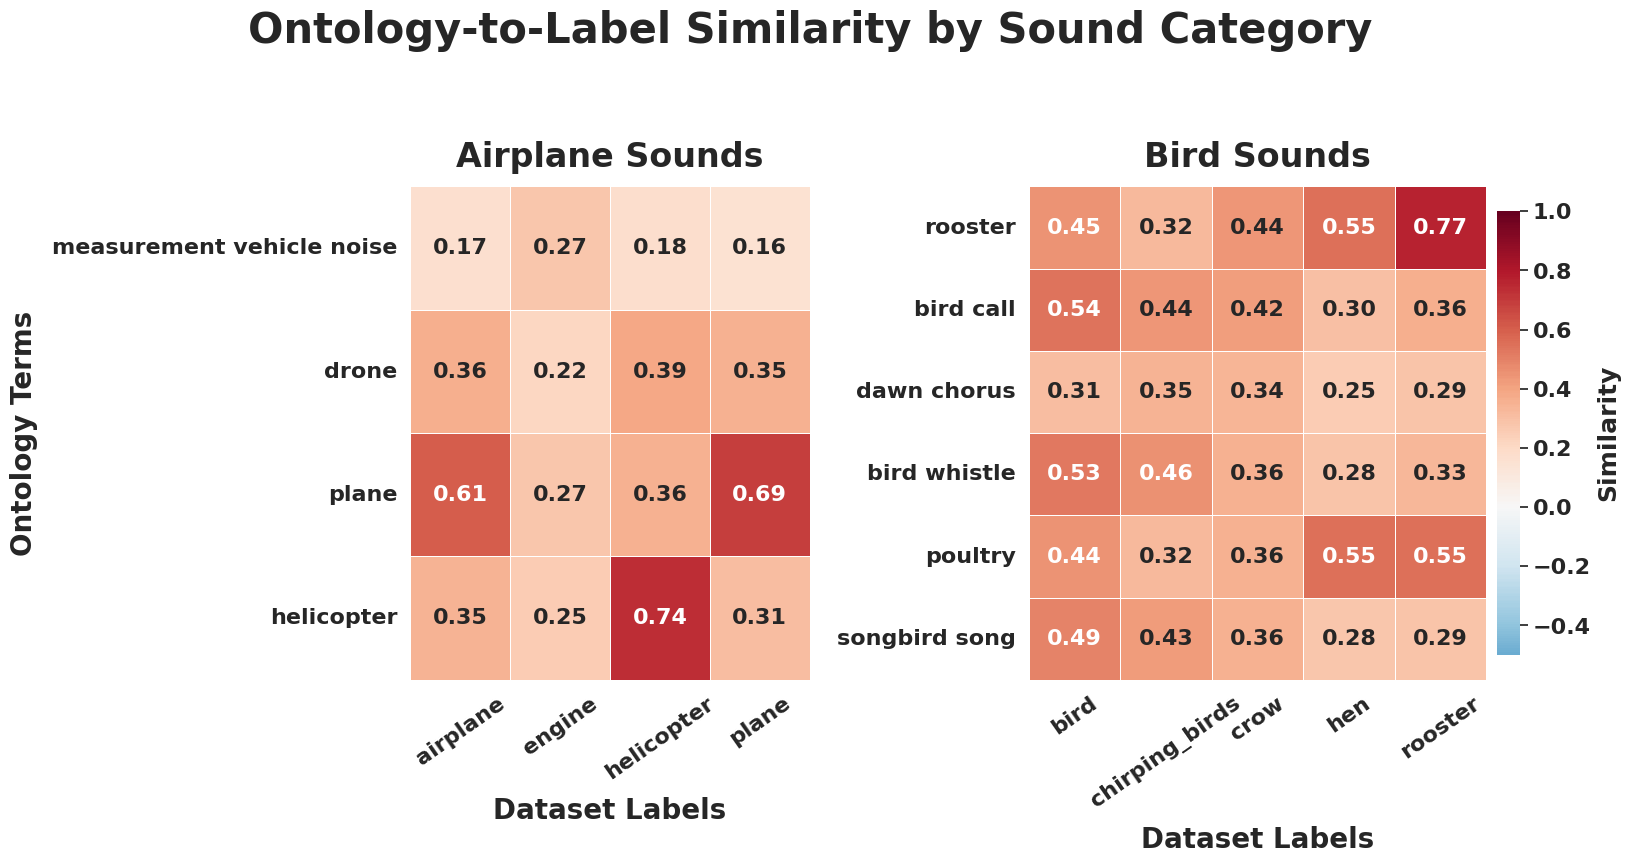


Grouped correlation matrices (A4 horizontal, seaborn/matplotlib) saved as:
  - grouped_correlation_matrices_dissertation_A4.pdf
  - grouped_correlation_matrices_dissertation_A4.png
Airplane correlations shape: (4, 4)
Bird correlations shape: (6, 5)


In [40]:
# Create separate correlation matrices for Airplane and Bird categories (A4 horizontal, seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

airplane_corr = correlation_df.loc[
    [row for row in correlation_df.index if row in airplane_ontology],
    [col for col in correlation_df.columns if col in airplane_labels]
].copy()

bird_corr = correlation_df.loc[
    [row for row in correlation_df.index if row in bird_ontology],
    [col for col in correlation_df.columns if col in bird_labels]
].copy()

# A4-like landscape with reduced height for a more compact figure
A4_WIDTH_IN = 16.54
A4_HEIGHT_IN = 8.8

# Global style tuned for PDF readability
sns.set_theme(style='white')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 18,
    'font.weight': 'bold',
    'axes.titlesize': 24,
    'axes.titleweight': 'bold',
    'axes.labelsize': 20,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(A4_WIDTH_IN, A4_HEIGHT_IN),
    constrained_layout=False,
    gridspec_kw={'width_ratios': [0.42, 0.58]}
)

# Left panel: Airplane
sns.heatmap(
    airplane_corr,
    ax=axes[0],
    cmap='RdBu_r',
    vmin=0,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 16, 'weight': 'bold'},
    linewidths=0.5,
    linecolor='white',
    cbar=False
)
axes[0].set_title('Airplane Sounds', pad=14, weight='bold')
axes[0].set_xlabel('Dataset Labels', labelpad=10, weight='bold')
axes[0].set_ylabel('Ontology Terms', labelpad=10, weight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Right panel: Bird (with shared colorbar)
hm = sns.heatmap(
    bird_corr,
    ax=axes[1],
    cmap='RdBu_r',
    vmin=-0.5,
    vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 16, 'weight': 'bold'},
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    cbar_kws={'label': 'Similarity', 'shrink': 0.9, 'pad': 0.02}
)
axes[1].set_title('Bird Sounds', pad=14, weight='bold')
axes[1].set_xlabel('Dataset Labels', labelpad=10, weight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

# Make tick labels bold on both heatmaps
for ax in axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

# Make colorbar labels/ticks larger and bold for print
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight('bold')
cbar.set_label('Similarity', size=18, weight='bold')

fig.suptitle('Ontology-to-Label Similarity by Sound Category', fontsize=30, weight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# Save static A4 exports
fig.savefig('grouped_correlation_matrices_dissertation_A4.pdf', dpi=300, bbox_inches='tight')
fig.savefig('grouped_correlation_matrices_dissertation_A4.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nGrouped correlation matrices (A4 horizontal, seaborn/matplotlib) saved as:')
print('  - grouped_correlation_matrices_dissertation_A4.pdf')
print('  - grouped_correlation_matrices_dissertation_A4.png')
print(f'Airplane correlations shape: {airplane_corr.shape}')
print(f'Bird correlations shape: {bird_corr.shape}')

In [ ]:
# For each ontology term, find the best matching dataset labels
best_matches = []

for i, ont_term in enumerate(labels):
    similarities = correlation_matrix[i]
    # Get top 5 matches
    top_indices = np.argsort(similarities)[-5:][::-1]
    
    for rank, idx in enumerate(top_indices, 1):
        best_matches.append({
            'ontology_term': ont_term,
            'rank': rank,
            'dataset_label': all_dataset_labels[idx],
            'similarity': similarities[idx]
        })

best_matches_df = pd.DataFrame(best_matches)

print('\nTop 5 dataset label matches for each ontology term:')
print(f'Total matches: {len(best_matches_df)}')
best_matches_df.head(25)

In [ ]:
# Find all strong matches (similarity > 0.7)
strong_matches = best_matches_df[best_matches_df['similarity'] > 0.7].sort_values('similarity', ascending=False)

print(f'\nStrong matches (similarity > 0.7): {len(strong_matches)}')
strong_matches

In [ ]:
# For each dataset label, find which ontology terms match it best
label_coverage = []

for j, dataset_label in enumerate(all_dataset_labels):
    similarities = correlation_matrix[:, j]
    best_idx = np.argmax(similarities)
    
    label_coverage.append({
        'dataset_label': dataset_label,
        'best_ontology_term': labels[best_idx],
        'similarity': similarities[best_idx],
        'source_datasets': dataset_labels_df[dataset_labels_df['label'] == dataset_label]['sources'].values[0]
    })

label_coverage_df = pd.DataFrame(label_coverage).sort_values('similarity', ascending=False)

print('\nBest ontology term match for each dataset label:')
print(f'\nCoverage statistics:')
print(f'Labels with good match (>0.7): {len(label_coverage_df[label_coverage_df["similarity"] > 0.7])}')
print(f'Labels with moderate match (0.5-0.7): {len(label_coverage_df[(label_coverage_df["similarity"] >= 0.5) & (label_coverage_df["similarity"] <= 0.7)])}')
print(f'Labels with weak match (<0.5): {len(label_coverage_df[label_coverage_df["similarity"] < 0.5])}')

label_coverage_df